**MOST RECENT VERSION OF THIS FILE, CHECK GITHUB FOR PROGRESS!!**

In [1]:
import symlib

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

import numpy as np
import os

import scipy
from scipy import stats
from scipy.optimize import curve_fit
from scipy.stats import linregress

## Global variables:
*These globals are used by every function below --> this cell MUST be run before anything else*

In [2]:
## GLOBALS:
base_dir = "C:/Users/steph/Symphony"                           ## base directory, points to the container folder where the Symphony data files are

## list of suites to be analyzed
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "MWest", "EDEN_MilkyWay_8K", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
#suite_list = ["SymphonyLMC"]

## colors for confidence band, individual hosts, etc
colors = {"SymphonyLMC": "tab:purple",
          "SymphonyMilkyWay": "tab:blue",
          "MWest": "black",
          "EDEN_MilkyWay_8K": "#5098f2",
          "SymphonyGroup": "tab:green",
          "SymphonyLCluster": "tab:orange",
          "SymphonyCluster": "tab:red"}

## colors for mean lines
avg_colors = {"SymphonyLMC": (102/225, 0/255, 110/255),
              "SymphonyMilkyWay": (7/255, 0/255, 110/255),
              "MWest": (0, 0, 0),
              "EDEN_MilkyWay_8K": (37/255, 107/255, 194/255),
              "SymphonyGroup": (22/255, 112/255, 0/255),
              "SymphonyLCluster": (163/255, 90/255, 2/255),
              "SymphonyCluster": (128/255, 3/255, 3/255)}

labels = {"SymphonyLMC": "SymphonyLMC",
          "SymphonyMilkyWay": "SymphonyMilkyWay",
          "MWest": "MWest",
          "EDEN_MilkyWay_8K": "EDEN_MilkyWay_8K",
          "SymphonyGroup": "SymphonyGroup",
          "SymphonyLCluster": "SymphonyLCluster",
          "SymphonyCluster": "SymphonyCluster"}

min_particles: int = 300    ## minimum number of particles for a halo to be considered "well-resolved"
z_max: float = 16.0         ## maximum redshift to keep (inclusive)

## MAH parameters:
redshift_ticks = [16, 8, 4, 2, 1, 0.5, 0.25]                   ## ticks and labels for when x_axis = "redshift"
redshift_labels = ["16", "8", "4", "2", "1", "0.5", "0.25"]
z_xlim = (16.0, 0.05)
mah_host_lw = 0.5                       ## per-host linewidth
mah_host_alpha = 0.15                   ## host alpha (opacity)
mah_avg_lw = 1.25                       ## average linewidth
mah_confidence_band_alpha = 0.25        ## alpha (opacity) of the 16-84% confidence band

## SHMF parameters:
redshifts_shmf: list[float] = [0.0]
#redshifts_shmf: list[float] = [0.0]
n_bins: int = 150                                              ## number of mass bins
m_max: float = 1e15                                            ## mass of the highest mass bin
shmf_host_lw = 0.5                                             ## same as for MAHs, just for SHMFs
shmf_host_alpha = 0.15
shmf_avg_lw = 1.25
shmf_confidence_band_alpha = 0.25

## Mass accretion histories:
* A "mass accretion history" is the mass of the subhalo as a function of time (snapshot, scale factor, redshift, cosmic time, etc).
* Below we focus on HOST mass accretion histories
* A 300 particle cut and a "survival cut" are applied, to exclude any times where the host was not well-resolved or well-formed
* Functionality is separated into several helper functions, a "dataloader" which loads all the relevant data in once, and then some "statistics" functions and a "plotter" function.
* All of this will be combined with the other plots into one "master" function eventually, where a series of toggle-able parameters control what plot comes out.

In [94]:
## MAHs dataloader --> reading in data for creating MAHs for all suites in Symphony (+MWest, +EDEN eventually)
## inputs: base_dir, suite_list

## output will be a dictionary, with indexable (key, value) pairs
## the dataloader function will be built on a per-suite basis for simplicity


## HELPER FUNCTIONS:

## build_z_mask returns a numpy array of timesteps we want to keep
def build_z_mask(scale_factors: np.ndarray, suite: str):
    
    redshifts = (1.0 / scale_factors) - 1.0
    mask = redshifts <= z_max
    if suite == "MWest":
        ## MWest behavior is different for some reason?
        mask &= scale_factors <= 1.0
        
    return mask

## due to the masking, lists may be different sizes
## so we need to pad the shorter arrays with NaN until they all match the length of the longest one
## nan_padding returns a numpy array of left-padded so that all are the same length as the longest array,
## then stacks them into a 2D array with shape (n_arrays, length)
## left-padding aligns all the arrays at their z = 0 snapshot
def nan_padding(arrays: list[np.ndarray], length: int):
    
    padded = [np.concatenate([np.full(length - len(a), np.nan), a]) for a in arrays]
    
    return np.vstack(padded)


## per-suite dataloader; loads mass accretion history information for every host in a given suite
## inputs: base_dir (string), suite (string),
##         min_mass_resolution_limit (int, usually 300 particles), z_max (float, this is somewhat arbitrarily chosen),
##         verbose (bool, controls whether progress print statements are on or off)
## outputs dict with keys:
##         scale_factors        # np.ndarray, shape (T,)   – reference time axis
##         redshifts            # np.ndarray, shape (T,)
##         masses               # np.ndarray, shape (N, T)  – NaN where unresolved
##         host_scale_factors   # list[np.ndarray]       – per-host, unpadded
##         host_masses          # list[np.ndarray]       – per-host, unpadded
##         particle_mass        # float  – mp [M_sun/h] from first host
##         n_hosts              # int
##         suite                # str

def load_MAH_suite_data(base_dir: str, suite: str, min_particles: int = min_particles, z_max: float = z_max, verbose: bool = True):
    
    n_hosts = symlib.n_hosts(suite)                 ## get the # of hosts (individual simulations in each folder)

    ## initializing empty lists to be filled later
    host_masses: list[np.ndarray] = []
    host_scale_factors: list[np.ndarray] = []
    particle_mass = None

    ## tracking any hosts that failed to load
    skipped_hosts: list[int] = []

    ## looping over hosts in a particular suite
    for i_host in range(n_hosts):
        if verbose:
            print(f"Loading host {i_host + 1} in suite {suite}", end = "\r", flush = True)

        try:
            sim_dir = symlib.get_host_directory(base_dir, suite, i_host)                ## getting the full directory to the host data
            h, hist = symlib.read_subhalos(sim_dir)                                     ## reading in the Symfind halo finder data

            ## storing particle mass for the first host (identical across a suite)
            if particle_mass is None:
                params = symlib.simulation_parameters(sim_dir)                          ## getting simulation parameters used in this suite
                particle_mass = float(params["mp"])                                     ## getting "macro-particle" mass used in this suite

            scale_factors = symlib.scale_factors(sim_dir)                               ## reading in per-host scale factors (resolves problems with masking)
            z_mask = build_z_mask(scale_factors, suite)
            scale_factors = scale_factors[z_mask]                                       ## applying the redshift cut

            ## getting host properties (host is always index 0)
            host_mass = np.array(h["mvir"][0])                                          ## host virial mass for all snapshots
            host_ok = np.array(h["ok"][0])                                              ## all snapshots where the host was properly identified by Symfind
            mass_cut = min_particles * particle_mass                                    ## 300 particles mass resolution limit

            ## applying the 300 particle resolution cut and the "ok" survival cut:
            ## keeping only snapshots where the host is "ok" AND "well-resolved" (at or above 300 particles)
            ## host_mass_masked *removes* these subhalos by replacing them with NaN
            host_mass_masked = np.where((host_mass < mass_cut) | ~host_ok, np.nan, host_mass)[z_mask]
            host_masses.append(host_mass_masked)
            host_scale_factors.append(scale_factors)

        except Exception as e:
            skipped_hosts.append(i_host)

            if verbose:
                print(f"\nSkipped host {i_host} in suite {suite}: {type(e).__name__}: {e}")

            continue

    if verbose:
        print()

        if skipped_hosts:
            print(f"Skipped {len(skipped_hosts)} corrupted host(s) in {suite}: {skipped_hosts}")

    ## use the host with the most snapshots as the reference time axis:
    ref_idx = int(np.argmax([len(s) for s in host_scale_factors]))
    ref_scale = host_scale_factors[ref_idx]
    max_len = len(ref_scale)
    masses_2D = nan_padding(host_masses, max_len)
    ref_redshift = (1.0 / ref_scale) - 1.0

    return {"suite": suite,
            "n_hosts": len(host_masses),              ## changing n_hosts to reflect only successfully loaded hosts
            "particle_mass": particle_mass,
            "scale_factors": ref_scale,               ## shape (T, )
            "redshifts": ref_redshift,                ## shape (T, )
            "masses": masses_2D,                      ## shape (N, T)
            "host_scale_factors": host_scale_factors, ## shape (N, T)
            "host_masses": host_masses,
            "skipped_hosts": skipped_hosts}


## function to automatically load all suites in suite_list, using load_MAH_suite_data:
def load_all_MAH_data(base_dir: str, suites = list[str], min_particles: int = min_particles, z_max: float = z_max, verbose: bool = True):
    
    if suites is None:
        suites = suite_list   ## defaults to the global string
    all_MAH_data: dict[str, dict] = {}
    
    for index, suite in enumerate(suites):
        all_MAH_data[suite] = load_MAH_suite_data(base_dir, suite, min_particles = min_particles, z_max = z_max, verbose = verbose)
        
    return all_MAH_data

## entrypoint to load the data
MAH_data = load_all_MAH_data(base_dir, suite_list)

Loading host 1 in suite EDEN_MilkyWay_8K
Skipped host 0 in suite EDEN_MilkyWay_8K: FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/steph/Symphony\\EDEN_MilkyWay_8K\\Halo023\\halos\\subhalos.dat'
Loading host 29 in suite EDEN_MilkyWay_8K
Skipped host 28 in suite EDEN_MilkyWay_8K: FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/steph/Symphony\\EDEN_MilkyWay_8K\\Halo738\\halos\\subhalos.dat'
Loading host 46 in suite EDEN_MilkyWay_8K
Skipped host 45 in suite EDEN_MilkyWay_8K: FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/steph/Symphony\\EDEN_MilkyWay_8K\\Halo119_m\\halos\\subhalos.dat'
Loading host 47 in suite EDEN_MilkyWay_8K
Skipped host 46 in suite EDEN_MilkyWay_8K: FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/steph/Symphony\\EDEN_MilkyWay_8K\\Halo364_m\\halos\\subhalos.dat'
Loading host 48 in suite EDEN_MilkyWay_8K
Skipped host 47 in suite EDEN_MilkyWay_8K: FileNotFoundError: [Errno 2] No such file or director

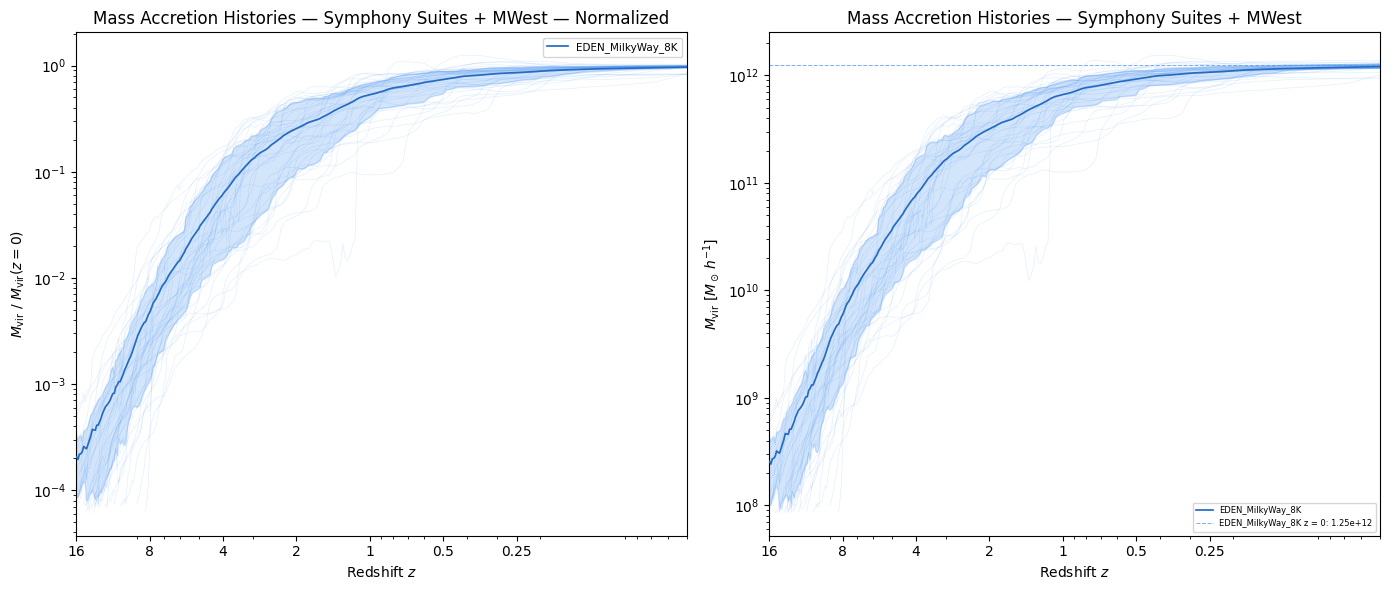

In [95]:
## STATISTICS + PLOTTER:

## STATISTICS: computes mean, median, standard deviation and 16-84% confidence band
def compute_MAH_stats(suite_data: dict):

    masses = suite_data["masses"]                    # (N, T)
    scale_factors = suite_data["scale_factors"]      # (T,)
    redshifts = suite_data["redshifts"]              # (T,)

    ## check that at least one host is well resolved at a particular timestep:
    n_resolved = np.sum(~np.isnan(masses), axis = 0) # (T,)         ## ~np.isnan gives all where the value is NOT NaN
    valid_mask = n_resolved > 0                      # (T,) bool

    ## using nan-sensitive functions
    mean = np.nanmean(masses, axis = 0)              # (T,)
    median = np.nanmedian(masses, axis = 0)          # (T,)
    std = np.nanstd(masses, axis = 0)                # (T,)
    p16 = np.nanpercentile(masses, 16, axis = 0)     # (T,)
    p84 = np.nanpercentile(masses, 84, axis = 0)     # (T,)

    # use the last snapshot where at least one host is resolved,
    # rather than blindly taking index [-1] which may be all-NaN.
    valid_indices = np.where(valid_mask)[0]
    final_mass = float(mean[valid_indices[-1]]) if len(valid_indices) > 0 else np.nan

    return {"suite": suite_data["suite"],
            "scale_factors": scale_factors,
            "redshifts": redshifts,
            "mean": mean,
            "median": median,
            "std": std,
            "p16": p16,
            "p84": p84,
            "final_mass": final_mass,
            "valid_mask": valid_mask,
            "n_resolved": n_resolved}

## function to run the statistics over all suites
def compute_all_MAH_stats(all_MAH_data: dict[str, dict]):
    
    all_MAH_stats = {suite: compute_MAH_stats(suite_data) for suite, suite_data in all_MAH_data.items()}
    
    return all_MAH_stats


## MAIN PLOTTER:

## plotting helpers:

## getting the correct x-axis
def get_xaxis(suite_stats: dict, x_axis: str):
    
    if x_axis == "scale_factor":
        return suite_stats["scale_factors"]
    elif x_axis == "redshift":
        return suite_stats["redshifts"]
    else:
        raise ValueError(f"x_axis must be 'scale_factor' or 'redshift', but got {x_axis!r}")

## configuring axes
def ax_config_MAH(ax: matplotlib.axes.Axes, x_axis: str):
    
    ax.set_yscale("log")
    ax.set_ylabel(r"$M_\mathrm{vir}\ [M_\odot\,h^{-1}]$", fontsize = 10)

    if x_axis == "scale_factor":
        ax.set_xlabel("Scale Factor $a$", fontsize = 10)

    elif x_axis == "redshift":
        ax.set_xscale("log")
        ax.set_xticks(redshift_ticks)
        ax.set_xticklabels(redshift_labels)
        ax.set_xlim(z_xlim)
        ax.set_xlabel(r"Redshift $z$", fontsize = 10)

## plotting per-suite data:
def plot_suite_MAH(ax: matplotlib.axes.Axes, suite: str, suite_data: dict, suite_stats: dict, x_axis: str,
                   show_hosts: bool = True, show_confidence: bool = True):

    color = colors[suite]
    avg_color = avg_colors[suite]
    valid = suite_stats["valid_mask"]
    x = get_xaxis(suite_stats, x_axis)

    ## individual hosts:
    if show_hosts:
        for host_sf, host_mass in zip(suite_data["host_scale_factors"], suite_data["host_masses"]):

            ## each host has its own time axis:
            host_x = host_sf if x_axis == "scale_factor" else ((1.0 / host_sf) - 1.0)
            ax.plot(host_x, host_mass, color = color, lw = mah_host_lw, alpha = mah_host_alpha)

    ## 16-84% confidence band:
    if show_confidence:
        ax.fill_between(x[valid], suite_stats["p16"][valid], suite_stats["p84"][valid], color = color, alpha = mah_confidence_band_alpha)

    ## mean:
    ax.plot(x[valid], suite_stats["mean"][valid], color = avg_color, lw = mah_avg_lw, zorder = 3, label = suite)

    ## final mass line:
    fm = suite_stats["final_mass"]
    if np.isfinite(fm):
        ax.axhline(fm, color = colors[suite], linestyle = "--", lw = 0.75, alpha = 0.75, label = f"z = 0 mass: {fm:.2e}")


## adding the option to normalize by the z = 0 mass accretion history:

## computing z = 0 normalized masses:
def compute_normalized_masses(suite_data: dict):
    
    masses = suite_data["masses"].copy()
    z0_masses = masses[:, -1]
    norm_masses = masses / z0_masses[:, np.newaxis]

    return norm_masses

def plot_suite_MAH_normalized(ax: matplotlib.axes.Axes, suite: str, suite_data: dict, suite_stats: dict, x_axis: str,
                              show_hosts: bool, show_confidence: bool = True):

    color = colors[suite]
    avg_color = avg_colors[suite]
    valid = suite_stats["valid_mask"]
    x = get_xaxis(suite_stats, x_axis)
    fm = suite_stats["final_mass"]

    norm_masses = compute_normalized_masses(suite_data)
    norm_mean   = np.nanmean(norm_masses, axis = 0)
    norm_p16    = np.nanpercentile(norm_masses, 16, axis = 0)
    norm_p84    = np.nanpercentile(norm_masses, 84, axis = 0)

    ## individual hosts normalized by their own z=0 mass:
    if show_hosts:
        for host_sf, host_mass in zip(suite_data["host_scale_factors"], suite_data["host_masses"]):
            host_x  = host_sf if x_axis == "scale_factor" else ((1.0 / host_sf) - 1.0)
            host_fm = host_mass[-1]
            if np.isfinite(host_fm) and host_fm != 0:
                ax.plot(host_x, host_mass / host_fm, color = color, lw = mah_host_lw, alpha = mah_host_alpha)

    if show_confidence:
        ax.fill_between(x[valid], norm_p16[valid], norm_p84[valid], color = color, alpha = mah_confidence_band_alpha)
    ax.plot(x[valid], norm_mean[valid], color = avg_color, lw = mah_avg_lw, zorder = 3, label = suite)

## putting it all together:
## all_MAH_data = data dictionary from load_all_MAH_data
## all_MAH_stats = data dictionary from compute_all_MAH_stats
## outputs a single-panel figure (or double-panel if "dual" = True)

def plot_all_MAH(all_MAH_data: dict[str, dict], all_MAH_stats: dict[str, dict], suites: list[str],
                 x_axis: str = "scale_factor", show_hosts: bool = True, dual: bool = False, show_confidence: bool = False,
                 figsize_single: tuple[float, float] = (7, 6), figsize_dual: tuple[float, float] = (14, 6),
                 title: str = "Mass Accretion Histories — Symphony Suites + MWest"):

    if suites is None:
        suites = [s for s in suite_list if s in all_MAH_data]

    figsize = figsize_dual if dual else figsize_single
    ncols = 2 if dual else 1
    
    fig, axes = plt.subplots(ncols = ncols, figsize = figsize)
    
    ax_main = axes[1] if dual else axes
    ax_norm = axes[0] if dual else None

    for suite in suites:
        plot_suite_MAH(ax_main, suite, all_MAH_data[suite], all_MAH_stats[suite], x_axis = x_axis, show_hosts = show_hosts, show_confidence = show_confidence)

        if dual:
            plot_suite_MAH_normalized(ax_norm, suite, all_MAH_data[suite], all_MAH_stats[suite], x_axis = x_axis, show_hosts = show_hosts, show_confidence = show_confidence)

    ax_config_MAH(ax_main, x_axis)
    
    if dual:
        ax_config_MAH(ax_norm, x_axis)
        #ax_norm.set_yscale("linear")
        ax_norm.set_ylabel(r"$M_\mathrm{vir}\ /\ M_\mathrm{vir}(z{=}0)$", fontsize = 10)

    legend_handles = []
    for s in suites:
        legend_handles.append(Line2D([0], [0], color = avg_colors[s], lw = mah_avg_lw, label = s))
        if np.isfinite(all_MAH_stats[s]["final_mass"]):
            legend_handles.append(Line2D([0], [0], color = colors[s], lw = 0.75, alpha = 0.75, linestyle = "--",
                                         label = f"{s} z = 0: {all_MAH_stats[s]['final_mass']:.2e}"))
            
    ax_main.legend(handles = legend_handles, loc = "best", fontsize = 6)
    ax_main.set_title(title, fontsize = 12)

    if dual:
        ## normalized panel only needs suite name labels, no final mass lines
        norm_handles = [Line2D([0], [0], color = avg_colors[s], lw = mah_avg_lw, label = s) for s in suites]
        ax_norm.legend(handles = norm_handles, loc = "best", fontsize = 7.5)
        ax_norm.set_title(f"{title} — Normalized", fontsize = 12)

    
    fig.tight_layout()

    return fig, axes

## entrypoint to generate stats & plots
MAH_stats = compute_all_MAH_stats(MAH_data)
fig, axes = plot_all_MAH(MAH_data, MAH_stats, suite_list, x_axis = "redshift", show_hosts = True, dual = True, show_confidence = True)

#fig.savefig(f"All MilkyWay MAHs", dpi = 250, bbox_inches = "tight")
plt.show()

## Subhalo Mass Functions:
* "Subhalo mass functions" are histograms of # of subhalos separated by mass.
* 300 particle cut and "ok" survival cut also apply here, but only as a threshold for transitioning the line from solid to dashed
* Host is NOT included; this focuses on SUBHALOS
* Two kinds: differential and cumulative
* Differential --> slope expected to be ~ -1.9 to -2.0
* Cumulative --> slope expected to be ~ -0.9 to -1.0
* All of the functions will be incorporated into one "master" dataloader and plotting function eventually

Starting SHMF plot for redshifts: [0.0]
Suites: ['EDEN_MilkyWay_8K']
Toggles — host lines: False, confidence band: True, linear fit: True, differential: False, convergence: True


Plotting panel for z = 0.0...
Computing SHMF for EDEN_MilkyWay_8K at z = 0.0 (57 hosts)...
Host 1/57
Host 29/57
Host 46/57
Host 47/57
Host 48/57
Host 49/57
Host 50/57
Host 51/57
Host 52/57
Host 53/57
Host 54/57
Host 55/57
Host 56/57
Host 57/57

Loaded 43/57 hosts.
Failed hosts: [0, 28, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56]
Convergence limit: 1.208e+08 M_sun
EDEN_MilkyWay_8K: slope = -0.875, intercept = 8.935, R² = 0.9973
Panel for z = 0.0 complete.


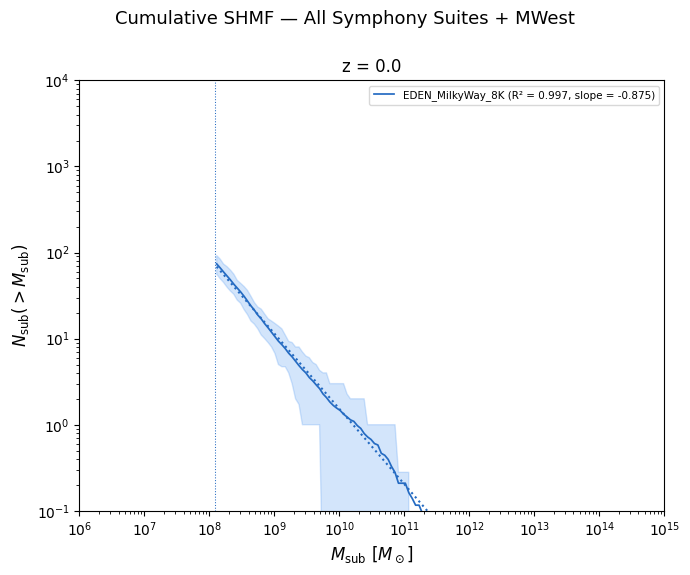

In [97]:
#TOGGLES:
## plot individual per-host lines
show_hosts_shmf = False

## plot 16-84% confidence band
show_confidence_shmf = True

## plot linear fit to mean SHMF. True = on
## two points used for the linear fit:
## 1. bin corresponding to 300 particles
## 2. bin corresponding to where the mean SHMF crosses the 10^-1 point on the y-axis
show_linear_fit = True

## if True, plot dN/d(log Msub) (differential SHMF) instead of cumulative SHMF
show_differential = False

## if True, show the vertical line at 300 * mp (convergence)
convergence = True

## if True, the SHMF below 300 * mp is shown
show_dashed = False

#######################################################################################################################

## HELPERS:

## returns the snapshot closest to a given redshift
def snap_at_redshift(sim_dir, target_z):
    
    scale = symlib.scale_factors(sim_dir)
    a_target = 1.0 / (1.0 + target_z)
    
    return int(np.argmin(np.abs(scale - a_target)))

## returns the cumulative N(>Msub) array and host virial mass for one host
## at a given snapshot --> subhalos must be ok, within R_vir, and not the host
def host_cumul_shmf(sim_dir, snap, bins):

    h, hist = symlib.read_subhalos(sim_dir)
    host = h[0, snap]
    r_host = host["rvir"]
    m_host = host["mvir"]

    ## vector from host center (Symlib automatically puts (0, 0, 0) at host center)
    sub_x = h[:, snap]["x"]      ## returns (x, y, z) location of subhalo center
    r = np.sqrt(np.sum(sub_x**2, axis = 1))

    ## subhalo is valid if "ok" at the given snapshot and inside the host virial radius
    ok = (h["ok"][:, snap] & (r < r_host))
    ok[0] = False            ## exclude the host
    m_sub = h["mvir"][:, snap][ok]    ## virial mass of all subhalos at the given snapshot

    ## cumulative histogram: N(> M) = total - cumsum from left
    n, _ = np.histogram(m_sub, bins = bins)
    n_cumul = np.cumsum(n[::-1])[::-1].astype(float)

    return n_cumul, m_host

def host_diff_shmf(sim_dir, snap, bins):
    
    h, hist = symlib.read_subhalos(sim_dir)
    host = h[0, snap]
    r_host = host["rvir"]
    m_host = host["mvir"]

    sub_x = h[:, snap]["x"]
    r = np.sqrt(np.sum(sub_x**2, axis = 1))

    ok = (h["ok"][:, snap] & (r < r_host))
    ok[0] = False
    m_sub = h["mvir"][:, snap][ok]

    n, _ = np.histogram(m_sub, bins = bins)

    ## divide by d(log M) per bin to get dN/d(log M)
    log_bins = np.log10(bins)
    d_log_m = np.diff(log_bins)
    diff = (n / d_log_m).astype(float)

    return diff, m_host
    
#######################################################################################################################

## DATALOADER:
## loops over all hosts in a suite at a given redshift
## returns:
## bin_centers: x-axis mass values, shape (n_bins,)
## all_ncumul: per-host cumulative SHMFs, shape (n_hosts, n_bins)
## conv_masses: 300 * mp in M_sun for each host, shape (n_hosts,)
def load_suite_shmf(suite, target_z):
    
    n_hosts = symlib.n_hosts(suite)
    print(f"Computing SHMF for {suite} at z = {target_z} ({n_hosts} hosts)...")

    snap = None            ## will be set from the first host
    bins = None            ## will be set from first host (per suite)
    bin_centers = None
    all_ncumul = []        ## one row per host
    all_ndiff = []
    conv_masses = []       ## 300 * mp in Msun for each host
    host_masses = []
    failed_hosts = []

    for i_host in range(n_hosts):
        sim_dir = symlib.get_host_directory(base_dir, suite, i_host)
        print(f"Host {i_host + 1}/{n_hosts}", end = "\r")

        try:
            if snap is None:
                snap = snap_at_redshift(sim_dir, target_z)

            ## getting particle mass
            params = symlib.simulation_parameters(sim_dir)
            mp = params["mp"] / params["h100"]

            ## define bins for this suite on first host
            ## lower edge = one decade below the convergence limit (so the dashed region has room)
            ## all hosts in a suite share the same particle mass, so this only has to be done once
            if bins is None:
                m_min_suite = min_particles * mp * 0.1
                bins = np.logspace(np.log10(m_min_suite), np.log10(m_max), n_bins + 1)
                bin_centers = np.sqrt(bins[:-1] * bins[1:])

            n_cumul, m_host = host_cumul_shmf(sim_dir, snap, bins)
            n_diff, _ = host_diff_shmf(sim_dir, snap, bins)

            ## skip hosts with no subhalos at this snapshot:
            if np.all(n_cumul == 0):
                print(f"\nWarning: host {i_host} has no subhalos at z = {target_z}, skipping.")
                continue
        
            all_ncumul.append(n_cumul)
            all_ndiff.append(n_diff)
            conv_masses.append(min_particles * mp)   ## convergence limit in physical Msun
            host_masses.append(m_host)

        except Exception as e:
            print(f"\nWarning: host {i_host} failed to load ({type(e).__name__}: {e}), skipping.")
            failed_hosts.append(i_host)
            continue

    print()   ## newline after \r
    print(f"Loaded {len(all_ncumul)}/{n_hosts} hosts.")
    if failed_hosts:
        print(f"Failed hosts: {failed_hosts}")

    return bin_centers, np.array(all_ncumul), np.array(all_ndiff), np.array(conv_masses), np.array(host_masses)

#######################################################################################################################

## STATISTICS
## computes summary statistics from the per-host SHMF array
## returns:
## mean_ncumul: mean cumulative SHMF across hosts, shape (n_bins,)
## p16, p84: 16th and 84th percentiles of host-to-host scatter
## median_conv_mass: median convergence limit in M_sun across hosts
def compute_shmf_stats(all_n, conv_masses):
    
    mean_n = np.mean(all_n, axis = 0)
    p16 = np.percentile(all_n, 16, axis = 0)
    p84 = np.percentile(all_n, 84, axis = 0)
    median_conv_mass = np.median(conv_masses)

    print(f"Convergence limit: {median_conv_mass:.3e} M_sun")

    return mean_n, p16, p84, median_conv_mass

## fits a power law (linear in log-log space) to y over the mass ratio range
## fit_ratio min < M_sub/M_host < fit_ratio_max
## returns slope, intercept, R^2 and the fit x/y arrays for plotting
def fit_powerlaw(bin_centers, y, solid_mask, y_floor = 1e-1):
    
    fit_mask = solid_mask & (y > y_floor)

    if np.sum(fit_mask) < 2:
        print("Warning: fewer than 2 bins in fit range, skipping fit.")
        return None

    log_x = np.log10(bin_centers[fit_mask])
    log_y = np.log10(y[fit_mask])

    slope, intercept, r, _, _ = linregress(log_x, log_y)
    r2 = r**2

    return slope, intercept, r2
    
#######################################################################################################################

## PLOTTER:
## plots the SHMF for one suite and one redshift on the given axes
## affected by the show_host_shmf and show_confidence_shmf toggles
def plot_suite_shmf(ax, suite, target_z):

    color = colors[suite]
    avg_color = avg_colors[suite]
    label = labels[suite]

    bin_centers, all_ncumul, all_ndiff, conv_masses, host_masses = load_suite_shmf(suite, target_z)
    #median_host_mass = np.median(host_masses)
    n_hosts = all_ncumul.shape[0]

    ## choose differential or cumulative:
    if show_differential:
        mean_n, p16, p84, median_conv_mass = compute_shmf_stats(all_ndiff, conv_masses)
        ylabel = r"$dN_{\rm sub}/d\log M_{\rm sub}$"
        all_n = all_ndiff

    else:
        mean_n, p16, p84, median_conv_mass = compute_shmf_stats(all_ncumul, conv_masses)
        ylabel = r"$N_{\rm sub}(> M_{\rm sub})$"
        all_n = all_ncumul

    ## solid-dashed split at the bin where x = median_conv_mass (min_particles * mp)
    solid_mask = bin_centers >= median_conv_mass
    dashed_mask = ~solid_mask

    p16_plot = p16.clip(min = 0.01)
    p84_plot = p84

    ## plot per-host lines:
    if show_hosts_shmf:
        for i in range(n_hosts):
            ax.plot(bin_centers[solid_mask], all_n[i][solid_mask], color = color, lw = shmf_host_lw, alpha = shmf_host_alpha)

            if show_dashed:
                ax.plot(bin_centers[dashed_mask], all_n[i][dashed_mask], color = color, lw = shmf_host_lw, alpha = shmf_host_alpha, linestyle = "--")

    ## plot mean line:
    ax.plot(bin_centers[solid_mask], mean_n[solid_mask], color = avg_color, lw = shmf_avg_lw, label = label)
    if show_dashed:
        ax.plot(bin_centers[dashed_mask], mean_n[dashed_mask], color = avg_color, lw = shmf_avg_lw)

    ## plot 16-84% confidence band
    if show_confidence_shmf:
        ax.fill_between(bin_centers[solid_mask], p16_plot[solid_mask], p84_plot[solid_mask], color = color, alpha = shmf_confidence_band_alpha)
        if show_dashed:
            ax.fill_between(bin_centers[dashed_mask], p16_plot[dashed_mask], p84_plot[dashed_mask], color = color, alpha = shmf_confidence_band_alpha)

    ## vertical line at convergence limit:
    if convergence:
        ax.axvline(median_conv_mass, color = avg_color, lw = 0.75, linestyle = ":")

    ## linear fit:
    slope_out = None
    r2_out = None
    if show_linear_fit:
        result = fit_powerlaw(bin_centers, mean_n, solid_mask)
        if result is not None:
            slope, intercept, r2 = result
            slope_out = slope
            r2_out = r2
            x_plot = bin_centers[solid_mask & (mean_n > 0)]
            y_plot = 10**(intercept + slope * np.log10(x_plot))
            ax.plot(x_plot, y_plot, color = avg_color, lw = 1.5, linestyle = ":")
            print(f"{label}: slope = {slope:.3f}, intercept = {intercept:.3f}, R² = {r2:.4f}")

    return ylabel, r2_out, slope_out
    

## plots all suites on a single axes panel for a given redshift
def plot_redshift_panel(ax, target_z):
    
    print(f"\nPlotting panel for z = {target_z}...")

    ylabel = None
    r2_dict = {}
    slope_dict = {}
 
    for suite in suite_list:
        ylabel, r2, slope = plot_suite_shmf(ax, suite, target_z)
        r2_dict[suite] = r2
        slope_dict[suite] = slope
 
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$M_{\rm sub}\ [M_\odot]$", fontsize = 12)
    ax.set_ylabel(ylabel, fontsize = 12)
    ax.set_xlim(1e6, 1e15)
    ax.set_ylim(1e-1, 1e4)
    ax.set_title(f"z = {target_z}", fontsize = 12)
    
    handles, leg_labels = ax.get_legend_handles_labels()
    new_labels = []
    for suite, lbl in zip(suite_list, leg_labels):
        r2 = r2_dict.get(suite, None)
        slope = slope_dict.get(suite, None)
        if r2 is not None:
            new_labels.append(f"{lbl} (R² = {r2:.3f}, slope = {slope:.3f})")
        else:
            new_labels.append(lbl)
    
    ax.legend(handles, new_labels, fontsize = 7.5, framealpha = 0.75)
 
    print(f"Panel for z = {target_z} complete.")
    
#######################################################################################################################

## ENTRYPOINT:
print(f"Starting SHMF plot for redshifts: {redshifts_shmf}")
print(f"Suites: {suite_list}")
print(f"Toggles — host lines: {show_hosts_shmf}, confidence band: {show_confidence_shmf}, "
      f"linear fit: {show_linear_fit}, differential: {show_differential}, convergence: {convergence}\n")

n_redshifts = len(redshifts_shmf)
fig, axes = plt.subplots(1, n_redshifts, figsize = (7 * n_redshifts, 6), squeeze = False)

for col, target_z in enumerate(redshifts_shmf):
    plot_redshift_panel(axes[0, col], target_z)

shmf_type = "Differential" if show_differential else "Cumulative"
fig.suptitle(f"{shmf_type} SHMF — All Symphony Suites + MWest", fontsize = 13, y = 0.95)
plt.tight_layout(rect = [0, 0, 1, 0.95])
plt.savefig("EDEN SHMF + linear fit.png", dpi = 150)
plt.show()

# N_subs(z) vs. Host_Mass(z)
* Looking at how the host mass accretion tracks with the # of subhalos as a function of "time" (redshift)

Loading suite SymphonyLMC... (39 hosts)
Host 39/39
Loaded 39/39 hosts (0 skipped)
RMSE_mass = 0.815530%, χ^2_mass = 0.323401
RMSE_nsubs = 2.170865%, χ^2_nsubs = 2.180653
Loading suite SymphonyMilkyWay... (45 hosts)
Host 45/45
Loaded 45/45 hosts (0 skipped)
RMSE_mass = 1.155816%, χ^2_mass = 0.525600
RMSE_nsubs = 2.858800%, χ^2_nsubs = 4.728385
Loading suite MWest... (20 hosts)
Host 20/20
Loaded 20/20 hosts (0 skipped)
RMSE_mass = 2.181864%, χ^2_mass = 0.512967
RMSE_nsubs = 3.985778%, χ^2_nsubs = 8.379864
Loading suite EDEN_MilkyWay_8K... (57 hosts)
Host 1/57
Skipping host 0: [Errno 2] No such file or directory: 'C:/Users/steph/Symphony\\EDEN_MilkyWay_8K\\Halo023\\halos\\subhalos.dat' in suite EDEN_MilkyWay_8K
Host 29/57
Skipping host 28: [Errno 2] No such file or directory: 'C:/Users/steph/Symphony\\EDEN_MilkyWay_8K\\Halo738\\halos\\subhalos.dat' in suite EDEN_MilkyWay_8K
Host 46/57
Skipping host 45: [Errno 2] No such file or directory: 'C:/Users/steph/Symphony\\EDEN_MilkyWay_8K\\Halo11

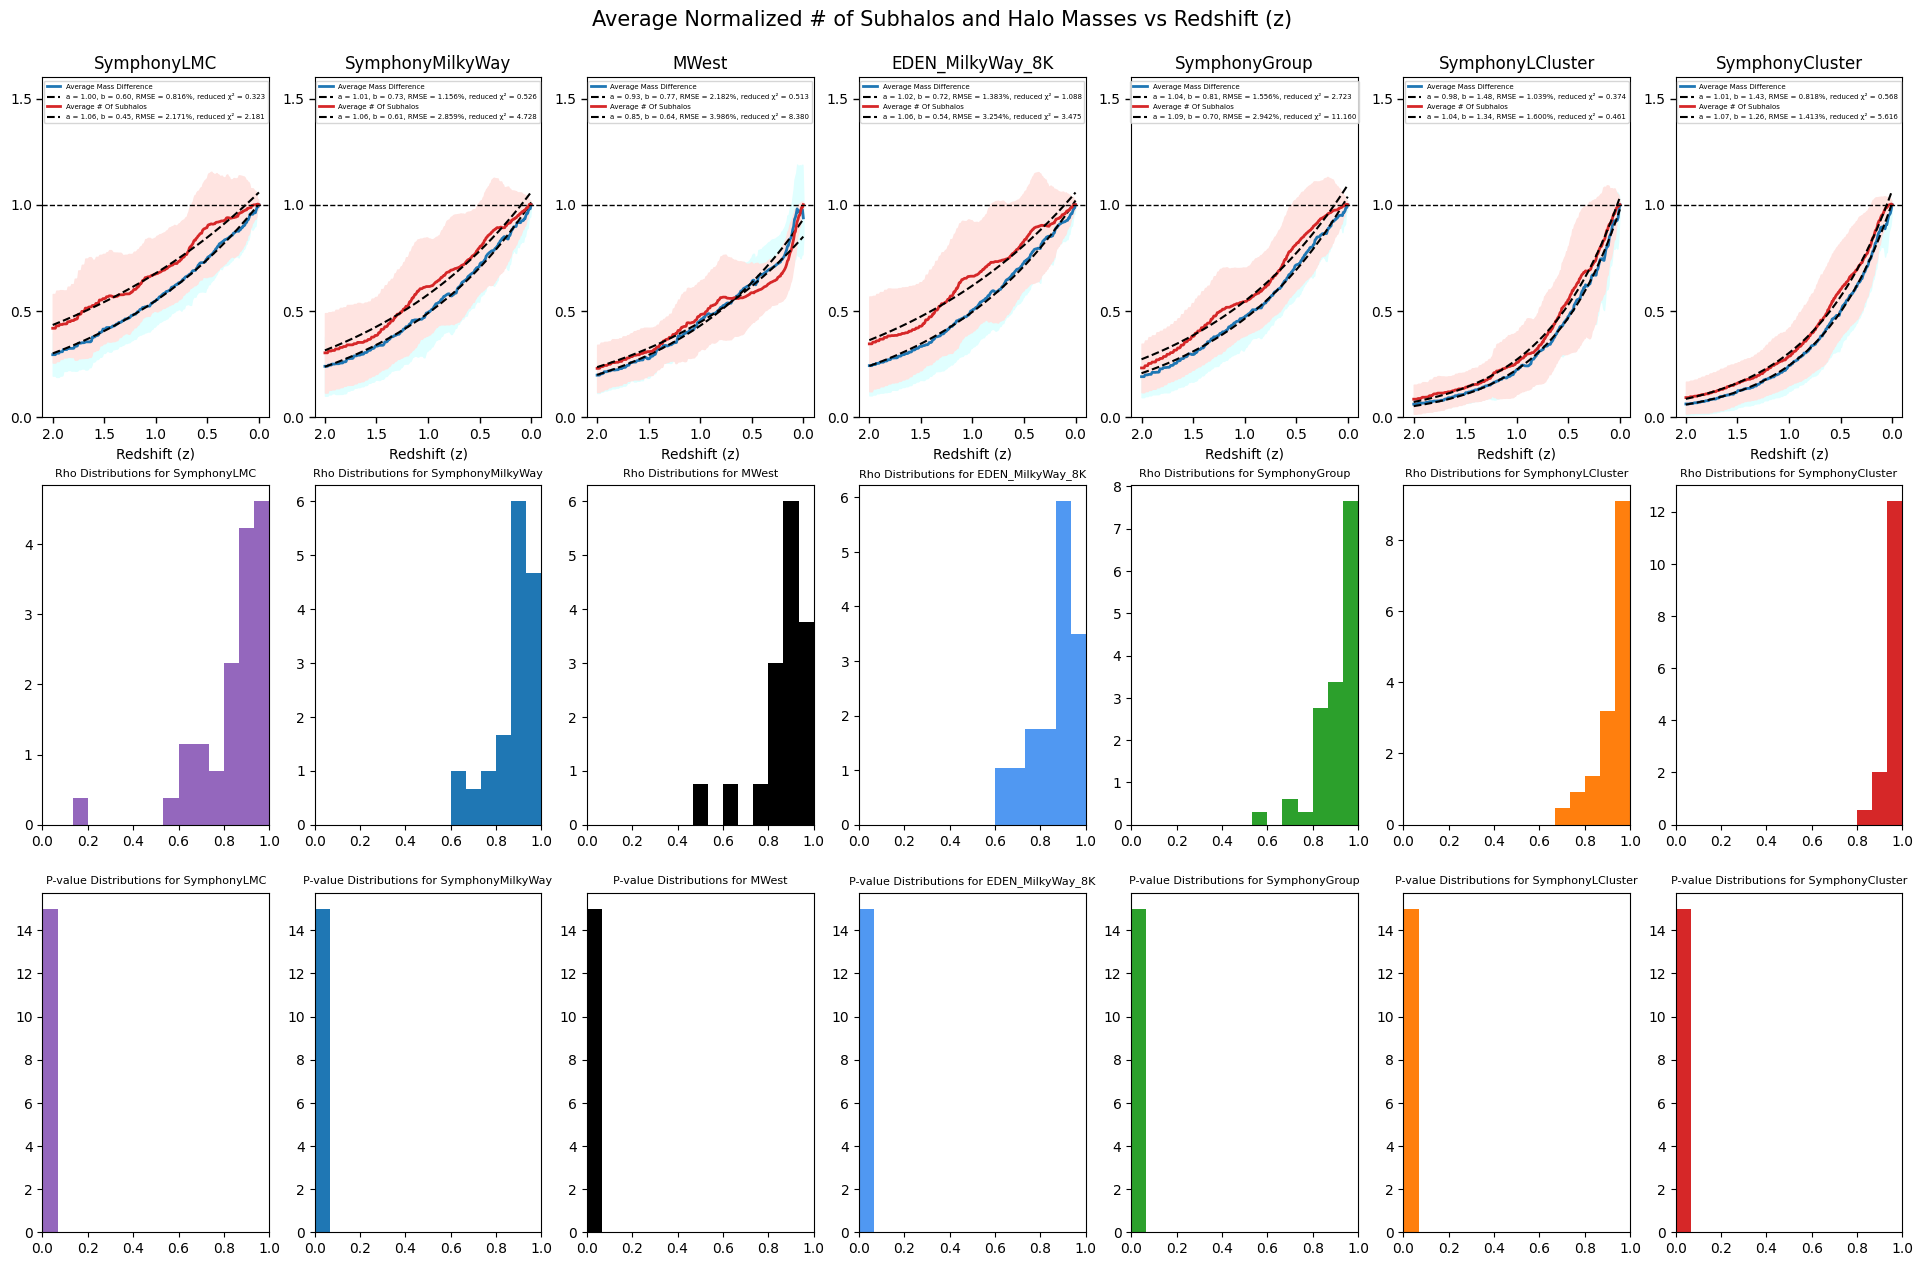

In [11]:
## defining the fitting functions from the Symphony paper
e = np.exp(1)

## FITTING FUNCTIONS:

## simple exponential decay model
def exponentialfit(x, a, b):
        return (a * e**(-1 * b * x))

## power-law + exponential correction (currently unused)
def linearcorrection(x, beta, gamma):
    return (((1 + x) ** beta) * (e ** (-1 * gamma * x)))

########################################################################################

## DATALOADER:

## useful maybe?
def get_mass_bins(suite_name, n_bins, m_max, min_particles):

    # get parameters for making histograms, as before:
    params = symlib.simulation_parameters(suite_name)
    m_min = params["mp"]/params["h100"] * min_particles
    bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
    left_bins = bins[:-1]

    return {"params": params,
            "m_min": m_min,
            "m_max": m_max,
            "bins": bins,
            "left_bins": left_bins,
            "h100": params["h100"]}

## reads the raw subhalo catalog for one host
def load_host(suite_name, i_host, base_dir):

    sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
    scale_factors = symlib.scale_factors(sim_dir)
    h, hist = symlib.read_subhalos(sim_dir)

    return {"sim_dir": sim_dir,
            "scale_factors": scale_factors,
            "h": h,
            "hist": hist}


## given raw host data from load_host, compute (at each snapshot between z = 2 and z = 0):
## 1. host mass - total mass in subhalos within host rvir
## 2. number of subhalos within host rvir
## returns the raw (non-normalized) curves + the z = 0 values needed to normalize them later
def compute_host_curves(host_data):
    
    h = host_data["h"]
    scale_factors = host_data["scale_factors"]
    redshifts = np.linspace(2, 0, len(scale_factors))
    
    mass_diffs = np.zeros(len(scale_factors))
    num_subhalos = np.zeros(len(scale_factors))
    tot_subhalo_mass_at_z = 0.0

    for z_index, target_z in enumerate(redshifts):
        target_a = 1 / (1 + target_z)
        snap_index = np.argmin(np.abs(scale_factors - target_a))

        host_rvir = h["rvir"][0, snap_index]
        host_pos = h["x"][0, snap_index]
        host_mass = h["mvir"][0, snap_index]

        sub_rvir = h["rvir"][1:, snap_index]
        sub_pos = h["x"][1:, snap_index]
        sub_mass = h["mvir"][1:, snap_index]

        ok = h["ok"][1:, snap_index]
        ok_sub_pos = sub_pos[ok]
        ok_sub_rvir = sub_rvir[ok]
        ok_sub_mass = sub_mass[ok]

        ## distance from host center:
        dist = np.sqrt(np.sum((ok_sub_pos - host_pos) ** 2, axis = 1))
        inside_host_rvir = dist < (host_rvir - ok_sub_rvir)

        num_subhalos[z_index] = np.sum(inside_host_rvir)
        valid_sub_masses = np.where(inside_host_rvir, ok_sub_mass, 0.0)
        tot_subhalo_mass_at_z = np.sum(valid_sub_masses)
        mass_diffs[z_index] = host_mass - tot_subhalo_mass_at_z

    z0_mass_diff = h["mvir"][0][-1] - tot_subhalo_mass_at_z
    z0_num_nsubs = num_subhalos[-1]

    return {"redshifts": redshifts,
            "mass_diffs": mass_diffs,
            "num_subhalos": num_subhalos,
            "z0_mass_diff": z0_mass_diff,
            "z0_num_nsubs": z0_num_nsubs}

## loading all hosts:
def load_suite_hosts(suite_name, base_dir):
    n_hosts = symlib.n_hosts(suite_name)
    print(f"Loading suite {suite_name}... ({n_hosts} hosts)")

    host_curves = []
    skipped_hosts = []
    for i_host in range(n_hosts):
        print(f"Host {i_host + 1}/{n_hosts}", end = "\r", flush = True)

        try:
            host_data = load_host(suite_name, i_host, base_dir)
            host_curves.append(compute_host_curves(host_data))

        except Exception as e:
            print(f"\nSkipping host {i_host}: {e} in suite {suite_name}")
            skipped_hosts.append((suite_name, i_host))
    print(f"\nLoaded {len(host_curves)}/{n_hosts} hosts ({len(skipped_hosts)} skipped)")
    return host_curves, skipped_hosts
    
#############################################################################################

## STATISTICS:

## normalize one host's raw mass_diffs & num_subhalos to their z0 value, and compute the Spearman rank correlation between them
def normalize_host_curves(curves):

    norm_mass_diffs = curves["mass_diffs"] / curves["z0_mass_diff"]
    norm_num_nsubs = curves["num_subhalos"] / curves["z0_num_nsubs"]

    rho, p = scipy.stats.spearmanr(norm_mass_diffs / np.max(norm_mass_diffs), norm_num_nsubs / np.max(norm_num_nsubs))

    return {"redshifts": curves["redshifts"],
            "norm_mass_diffs": norm_mass_diffs,
            "norm_num_nsubs": norm_num_nsubs,
            "rho": rho,
            "p": p}

## computes R^2
#def r_squared(y_data, y_model):  
#    y_data = np.asarray(y_data)
#    y_model = np.asarray(y_model)
#    ss_res = np.sum((y_data - y_model) ** 2)
#    ss_tot = np.sum((y_data - np.mean(y_model)) ** 2)
#    return 1 - ss_res / ss_tot

## computes the root-mean-squared error (RMSE) between the suite-averaged curve and the exponential fit
def rmse(y_data, y_model):

    y_data = np.asarray(y_data)
    y_model = np.asarray(y_model)

    return np.sqrt(np.mean((y_data - y_model)**2))

## computes the reduced chi-squared (residuals normalized by per-bin uncertainty)
## sigma here is the standard error of the mean (SEM, the standard deviation across hosts divided by sqrt(n_hosts))
def reduced_chi_squared(y_data, y_model, sigma, n_params):

    y_data = np.asarray(y_data)
    y_model = np.asarray(y_model)
    sigma = np.asarray(sigma)

    valid = sigma > 0
    chi_sq = np.sum(((y_data[valid] - y_model[valid]) / sigma[valid])**2)
    dof = np.sum(valid) - n_params

    return chi_sq / dof

## given a list of raw per_host curves:
## - normalize each host
## - average across hosts
## - fit each averaged curve with an exponential model
def aggregate_suite(host_curves):
    
    normalized = [normalize_host_curves(c) for c in host_curves]

    ## MWest and EDEN have different snapshot counts compared to Symphony suites
    ## interpolating onto a common gridspace (from z = 2 to z = 0, 235 snapshots)
    common_redshifts = np.linspace(2, 0, 235)

    def interp_host(n):
        return {"norm_mass_diffs": np.interp(common_redshifts, n["redshifts"][::-1], n["norm_mass_diffs"][::-1]),
                "norm_num_nsubs":  np.interp(common_redshifts, n["redshifts"][::-1], n["norm_num_nsubs"][::-1])}

    resampled = [interp_host(n) for n in normalized]

    redshifts = common_redshifts
    norm_mass_diffs = np.array([r["norm_mass_diffs"] for r in resampled])
    norm_num_nsubs  = np.array([r["norm_num_nsubs"]  for r in resampled])
 
    avg_norm_mass_diffs = np.mean(norm_mass_diffs, axis = 0)
    avg_norm_num_nsubs = np.mean(norm_num_nsubs, axis = 0)
    std_norm_mass_diffs = np.std(norm_mass_diffs, axis = 0)
    std_norm_num_nsubs = np.std(norm_num_nsubs, axis = 0)
 
    fit_mass, _ = curve_fit(exponentialfit, redshifts, avg_norm_mass_diffs)
    fit_nsubs, _ = curve_fit(exponentialfit, redshifts, avg_norm_num_nsubs)

    n_hosts = len(host_curves)
    sigma_mass = std_norm_mass_diffs / np.sqrt(n_hosts)
    sigma_nsubs = std_norm_num_nsubs / np.sqrt(n_hosts)
    
    rmse_mass = rmse(avg_norm_mass_diffs, exponentialfit(redshifts, *fit_mass))
    rmse_nsubs = rmse(avg_norm_num_nsubs, exponentialfit(redshifts, *fit_nsubs))
    
    reduced_chisq_mass  = reduced_chi_squared(avg_norm_mass_diffs,  exponentialfit(redshifts, *fit_mass),  sigma_mass,  n_params = 2)
    reduced_chisq_nsubs = reduced_chi_squared(avg_norm_num_nsubs, exponentialfit(redshifts, *fit_nsubs), sigma_nsubs, n_params = 2)

    print(f"RMSE_mass = {(rmse_mass * 100):2f}%, χ^2_mass = {(reduced_chisq_mass):2f}")
    print(f"RMSE_nsubs = {(rmse_nsubs * 100):2f}%, χ^2_nsubs = {(reduced_chisq_nsubs):2f}")
 
    return {"redshifts": redshifts,
            "avg_norm_mass_diffs": avg_norm_mass_diffs,
            "avg_norm_num_nsubs": avg_norm_num_nsubs,
            "std_norm_mass_diffs": std_norm_mass_diffs,
            "std_norm_num_nsubs": std_norm_num_nsubs,
            "fit_mass": fit_mass,
            "fit_nsubs": fit_nsubs,
            "rmse_mass": rmse_mass,
            "rmse_nsubs": rmse_nsubs,
            "reduced_chisq_mass": reduced_chisq_mass,
            "reduced_chisq_nsubs": reduced_chisq_nsubs,
            "rho_suite": [n["rho"] for n in normalized],
            "p_suite": [n["p"] for n in normalized]}

##################################################################################################################################

## PLOTTER:

## fill in one column of the 3-row figure (curves, rho hist, p hist for a single suite)
def plot_suite(axs, suite_index, suite_name, suite_result, colors):

    redshifts = suite_result["redshifts"]
    color = colors[suite_name]

    ax = axs[0, suite_index]
    ax.plot(redshifts, suite_result["avg_norm_mass_diffs"], color = "tab:blue", lw = 2, label = "Average Mass Difference")
    ax.fill_between(redshifts, suite_result["avg_norm_mass_diffs"] + suite_result["std_norm_mass_diffs"],
                    suite_result["avg_norm_mass_diffs"] - suite_result["std_norm_mass_diffs"], color = "lightcyan")
    ax.plot(redshifts, exponentialfit(redshifts, *suite_result["fit_mass"]), color = "black", linestyle = "--",
            label = f"a = {suite_result['fit_mass'][0]:.2f}, b = {suite_result['fit_mass'][1]:.2f}, "
                    f"RMSE = {(suite_result['rmse_mass']*100):.3f}%, reduced \u03C7\u00b2 = {suite_result['reduced_chisq_mass']:.3f}")

    ax.plot(redshifts, suite_result["avg_norm_num_nsubs"], color = "tab:red", lw = 2,
            label = "Average # Of Subhalos")
    ax.fill_between(redshifts, suite_result["avg_norm_num_nsubs"] + suite_result["std_norm_num_nsubs"],
                    suite_result["avg_norm_num_nsubs"] - suite_result["std_norm_num_nsubs"], color = "mistyrose")
    ax.plot(redshifts, exponentialfit(redshifts, *suite_result["fit_nsubs"]), color = "black", linestyle = "--",
            label = f"a = {suite_result['fit_nsubs'][0]:.2f}, b = {suite_result['fit_nsubs'][1]:.2f}, "
                    f"RMSE = {(suite_result['rmse_nsubs']*100):.3f}%, reduced \u03C7\u00b2 = {suite_result['reduced_chisq_nsubs']:.3f}")

    ax.invert_xaxis()
    ax.set_xlabel("Redshift (z)")
    ax.set_ylim(0.0, 1.6)
    ax.axhline(y = 1, color = "black", lw = 1, linestyle = "--")
    ax.locator_params(axis = "x", nbins = 5)
    ax.locator_params(axis = "y", nbins = 5)
    ax.tick_params(axis = "both", which = "major", length = 4, width = 1, direction = "out")
    ax.legend(fontsize = 5, loc = "upper center")
    ax.set_title(suite_name)

    ax_rho = axs[1, suite_index]
    ax_rho.hist(suite_result["rho_suite"], bins = 15, range = (0, 1), color = color, density = True)
    ax_rho.set_xlim(0, 1)
    ax_rho.set_title(f"Rho Distributions for {suite_name}", fontsize = 8)

    ax_p = axs[2, suite_index]
    ax_p.hist(suite_result["p_suite"], bins = 15, range = (0, 1), color = color, density = True)
    ax_p.set_xlim(0, 1)
    ax_p.set_title(f"P-value Distributions for {suite_name}", fontsize = 8)


## plotting all suites:
def plot_all_suites(suite_results, colors):

    suite_names = list(suite_results.keys())
    fig, axs = plt.subplots(ncols = len(suite_names), nrows = 3, figsize = (24, 15))

    for suite_index, suite_name in enumerate(suite_names):
        plot_suite(axs, suite_index, suite_name, suite_results[suite_name], colors)
        
    fig.suptitle("Average Normalized # of Subhalos and Halo Masses vs Redshift (z)", fontsize = 15)
    fig.tight_layout(rect = [0, 0, 1, 0.95])  ## leaves room for suptitle at the top
    fig.savefig("Nsubs vs. Host Masses [all suites!!] (RMSE + reduced χ^2).png", bbox_inches = "tight")
    plt.show()

    return fig, axs

#######################################################################################################################

## ENTRYPOINT:

def run_all_suites(suite_list, base_dir, colors):
    suite_results = {}
    all_skipped = []
    for suite_name in suite_list:
        host_curves, skipped_hosts = load_suite_hosts(suite_name, base_dir)
        all_skipped.extend(skipped_hosts)
        suite_results[suite_name] = aggregate_suite(host_curves)

    if all_skipped:
        print(f"\nSkipped hosts across all suites:")
        for suite_name, i_host in all_skipped:
            print(f"{suite_name}, host {i_host}")
 
    fig, axs = plot_all_suites(suite_results, colors)
    return fig, axs, suite_results, all_skipped
 
 
if __name__ == "__main__":
    fig, axs, suite_results, all_skipped = run_all_suites(suite_list, base_dir, colors)


# look at p-values and try to resolve the question regarding the delta-function-like behavior --> probably unphysical??
# upgrade the distance calculation and factor in the possibility of there being subhalos that are partially inside the host halo, especially at high redshift

0 0
All Objects Populated!
Saved!
1 5
All Objects Populated!
Saved!
2 10
All Objects Populated!
Saved!
3 15
All Objects Populated!
Saved!
4 20
All Objects Populated!
Saved!
5 25
All Objects Populated!
Saved!
6 30
All Objects Populated!
Saved!
7 35
All Objects Populated!
Saved!
8 40
All Objects Populated!
Saved!
9 45
All Objects Populated!
Saved!
10 50
All Objects Populated!
Saved!
11 55
All Objects Populated!
Saved!
12 60
All Objects Populated!
Saved!
13 65
All Objects Populated!
Saved!
14 70
All Objects Populated!
Saved!
15 75
All Objects Populated!
Saved!
16 80
All Objects Populated!
Saved!
17 85
All Objects Populated!
Saved!
18 90
All Objects Populated!
Saved!
19 95
All Objects Populated!
Saved!
20 100
All Objects Populated!
Saved!
21 105
All Objects Populated!
Saved!
22 110
All Objects Populated!
Saved!
23 115
All Objects Populated!
Saved!
24 120
All Objects Populated!
Saved!
25 125
All Objects Populated!
Saved!
26 130
All Objects Populated!
Saved!
27 135
All Objects Populated!
Sav

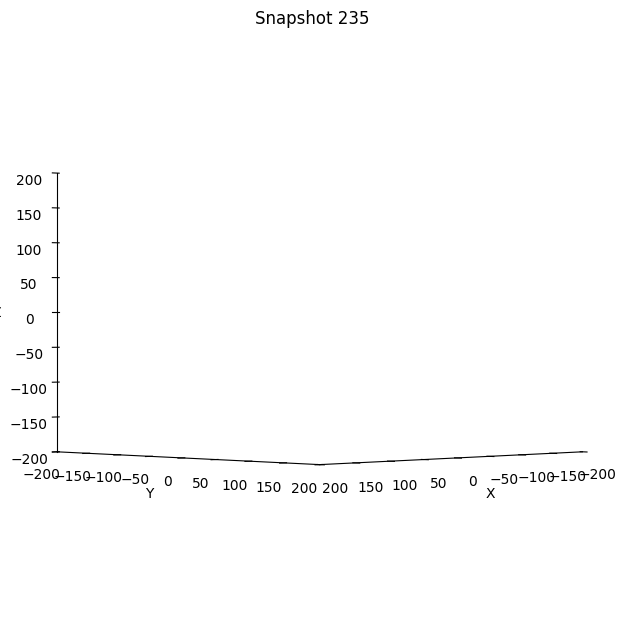

In [6]:
## GOAL: create a visualization that shows the behavior of subhalos in MWest over all snapshots
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation

base_dir = "C:/Users/steph/Symphony"
suite_list = ["MWest"]

image_directory = "mwest_visual/*.png"   # where to look for images to turn into a GIF, and where to save the GIF
output_directory = "mwest_visual"
output_gif_path = "mwest_visual.gif"

## create a 3-D plot that we can rotate and manipulate later to see what's going on
fig = plt.figure(figsize = (7.5, 7.5))
ax = fig.add_subplot(111, projection = '3d')

u = np.linspace(0, 2 * np.pi, 40)   # defining these rotation linspaces for later
v = np.linspace(0, np.pi, 20)

sphere_x = np.outer(np.cos(u), np.sin(v))
sphere_y = np.outer(np.sin(u), np.sin(v))
sphere_z = np.outer(np.ones_like(u), np.cos(v))

## now we need to read the location and virial radius data for every subhalo and plot it
for suite_index, suite in enumerate(suite_list):
    n_hosts = symlib.n_hosts(suite)

    host = "Halo113"

    sim_dir = symlib.get_host_directory(base_dir, suite, host)
    scale_factors = symlib.scale_factors(sim_dir)
    scale_factors = scale_factors[scale_factors <= 1]

    snapshots = np.arange(0, 240, 5)
        
    h, hist = symlib.read_subhalos(sim_dir)

    for snap_index, snap in enumerate(snapshots):
        print(snap_index, snap)
        
        filename = f"Snapshot {(snap):.2f}.png"
        full_path = os.path.join(output_directory, filename)

        host_rvir = h["rvir"][0, snap]
        host_mvir = h["mvir"][0, snap]
        host_pos = h["x"][0, snap]

        sub_rvir = h["rvir"][1:, snap]
        sub_pos = h["x"][1:, snap]
        
        ok1 = h["ok"][1:, snap]
        ok_sub_pos = sub_pos[ok1]
        ok_sub_rvir = sub_rvir[ok1]

        sub_dist = np.sqrt(np.sum(ok_sub_pos**2, axis=1))

        host_cx, host_cy, host_cz = host_center = host_pos[0], host_pos[1], host_pos[2]
        host_x = host_rvir * np.outer(np.cos(u), np.sin(v)) + host_cx
        host_y = host_rvir * np.outer(np.sin(u), np.sin(v)) + host_cy
        host_z = host_rvir * np.outer(np.ones(np.size(u)), np.cos(v)) + host_cz
        ax.plot_surface(host_x, host_y, host_z, color = "tab:purple",
                       rcount = 20, ccount = 20, shade = False, antialiased=False)

        for index, subhalo in enumerate(ok_sub_rvir):
            if (sub_dist[index] < host_rvir - ok_sub_rvir[index]):
                sub_cx, sub_cy, sub_cz = ok_sub_pos[index][0], ok_sub_pos[index][1], ok_sub_pos[index][2]
                sub_x = ok_sub_rvir[index] * sphere_x + sub_cx
                sub_y = ok_sub_rvir[index] * sphere_y + sub_cy
                sub_z = ok_sub_rvir[index] * sphere_z + sub_cz
                ax.plot_surface(sub_x, sub_y, sub_z, color = "tab:green",
                               rcount = 20, ccount = 20, shade = False, antialiased=False)
                

            elif (sub_dist[index] > host_rvir + ok_sub_rvir[index]):
                sub_cx, sub_cy, sub_cz = ok_sub_pos[index][0], ok_sub_pos[index][1], ok_sub_pos[index][2]
                sub_x = ok_sub_rvir[index] * sphere_x + sub_cx
                sub_y = ok_sub_rvir[index] * sphere_y + sub_cy
                sub_z = ok_sub_rvir[index] * sphere_z + sub_cz
                ax.plot_surface(sub_x, sub_y, sub_z, color = "tab:red",
                               rcount = 20, ccount = 20, shade = False, antialiased=False)

        ax.view_init(elev = 0, azim = 45)
        ax.set_xlim(-200, 200)
        ax.set_ylim(-200, 200)
        ax.set_zlim(-200, 200)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f"Snapshot {snap}")
    
        print("All Objects Populated!")
    
        plt.savefig(full_path, dpi = 80, facecolor = 'white')
        print("Saved!")

        ax.autoscale(enable=False)
        ax.grid(False)
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
        for coll in ax.collections[:]:
            coll.remove()

In [7]:
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

pop_image_paths = sorted(glob.glob(image_directory), key=lambda x: int(re.search(r"(\d+)", x).group()))
 
# Load images 
images = []
for path in pop_image_paths:
    img = Image.open(path)
    images.append(img)

if images:
    images[0].save(output_gif_path, save_all=True, append_images=images[1:], duration = 100, loop=0)
    print(f"GIF created and saved at {output_gif_path}")
else:
    print("No images found in the specified directory.")

GIF created and saved at mwest_visual.gif


1 200
2 200
3 200
4 200
5 200
6 200
7 200
8 200
9 200
10 200
11 200
12 200
13 200
14 200
15 200
16 200
17 200
18 200
19 200
20 200
21 200
22 200
23 200
24 200
25 200
26 200
27 200
28 200
29 200
30 200
31 200
32 200
33 200
34 200
35 200
36 200
37 200
38 200
39 200
40 200
41 200
42 200
43 200
44 200
45 200
46 200
47 200
48 200
49 200
50 200
51 200
52 200
53 200
54 200
55 200
56 200
57 200
58 200
59 200
60 200
61 200
62 200
63 200
64 200
65 200
66 200
67 200
68 200
69 200
70 200
71 200
72 200
73 200
74 200
75 200
76 200
77 200
78 200
79 200
80 200
81 200
82 200
83 200
84 200
85 200
86 200
87 200
88 200
89 200
90 200
91 200
92 200
93 200
94 200
95 200
96 200
97 200
98 200
99 200
100 200
101 200
102 200
103 200
104 200
105 200
106 200
107 200
108 200
109 200
110 200
111 200
112 200
113 200
114 200
115 200
116 200
117 200
118 200
119 200
120 200
121 200
122 200
123 200
124 200
125 200
126 200
127 200
128 200
129 200
130 200
131 200
132 200
133 200
134 200
135 200
136 200
137 200
138 200
139 

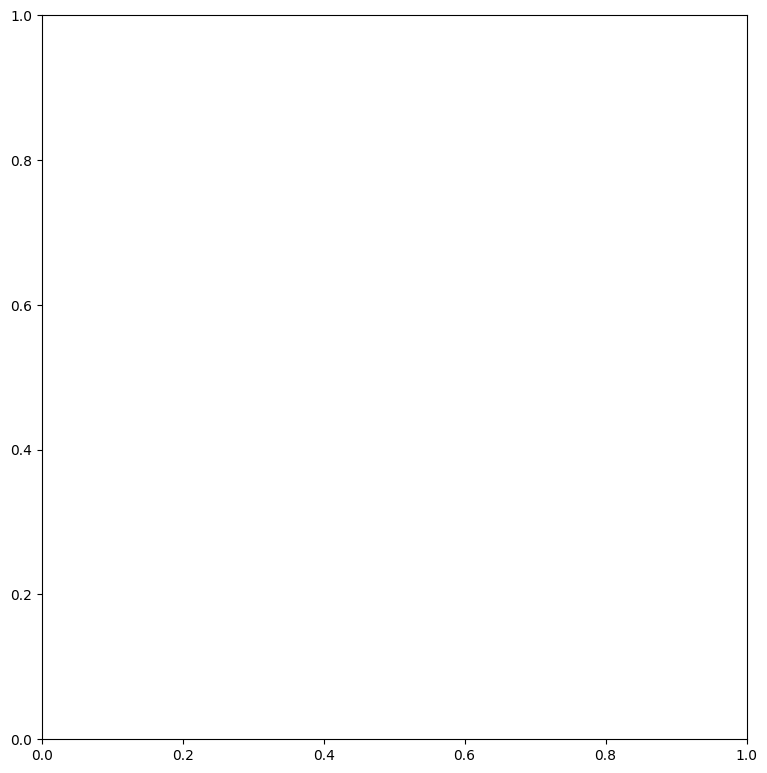

In [3]:
# generating subhalo location and mass vs time gifs!

from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

base_dir = "C:/Users/steph/Symphony"
suite_list = ["SymphonyCluster"]
image_directory = "subhalo_gif/*.png"
output_gif_path = "subhalo_animation.gif"

fig, ax = plt.subplots(ncols = 1, nrows = 1, figsize = (8, 8))

for suite_index, suite_name in enumerate(suite_list):
    n_hosts = symlib.n_hosts(suite_name)
    
    for i_host in range(1):
        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        scale_factors = symlib.scale_factors(sim_dir)
        h, hist = symlib.read_subhalos(sim_dir)

        for snap_index, snap in enumerate(scale_factors):
            host = h[0, snap_index]
            symlib.plot_circle(ax, host["x"][0], host["x"][1], host["rvir"], c = "tab:red")
            
            z0_radius = 100
        
            for i in range(1, len(h)):
                sub = h[i, snap_index]
                if sub["ok"]:
                    symlib.plot_circle(ax, sub['x'][0], sub['x'][1], sub['rvir'], c = "tab:blue", lw = 1.5)

            ax.set_xlim(-7*host["rvir"], 7*host["rvir"])
            ax.set_ylim(-7*host["rvir"], 7*host["rvir"])                            
            #ax.set_xlim(-3000, 3000)
            #ax.set_ylim(-3000, 3000)
            
            ax.set_title(f'a = {(snap):2f}')
            plt.tight_layout()
            
            output_directory = "subhalo_gif"
            filename = f"subhalo_image_{snap_index}.png"
            
            if not os.path.exists(output_directory):
                os.makedirs(output_directory)
                
            full_path = os.path.join(output_directory, filename)
            plt.savefig(full_path, dpi = 100, facecolor = 'white')

            if snap_index < len(scale_factors):
                print(snap_index + 1, len(scale_factors))
                ax.clear()

In [4]:
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

image_directory = "subhalo_gif/*.png"
output_gif_path = "subhalo_animation.gif"

image_paths = glob.glob(image_directory)
image_paths = sorted(glob.glob(image_directory), key=lambda x: int(re.search(r"(\d+)", x).group()))
 
# Load images 
images = []
for path in image_paths:
    img = Image.open(path)
    images.append(img)

if images:
    images[0].save(output_gif_path, save_all=True, append_images=images[1:], duration = 75, loop=0)
    print(f"GIF created and saved at {output_gif_path}")
else:
    print("No images found in the specified directory.")

GIF created and saved at subhalo_animation.gif
